In [5]:
%pip install kagglehub

import kagglehub

# Download latest version of BMW worldwide sales dataset
path = kagglehub.dataset_download("ahmadrazakashif/bmw-worldwide-sales-records-20102024")
print("Path to dataset files:", path)

  Using cached kagglehub-0.3.13-py3-none-any.whl.metadata (38 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


100%|██████████| 833k/833k [00:00<00:00, 4.68MB/s]

Extracting files...
Path to dataset files: C:\Users\balto\.cache\kagglehub\datasets\ahmadrazakashif\bmw-worldwide-sales-records-20102024\versions\1


In [21]:
import os
import pandas as pd


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Automatically find the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("CSV files found:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()
# Use your dataset already loaded as df or load it again:
# df = pd.read_csv("path_to_dataset.csv")

# Choose the variables for analysis
x = df["Mileage_KM"]
y = df["Price_USD"]

df[["Mileage_KM", "Price_USD"]].head()



CSV files found: ['BMW sales data (2010-2024) (1).csv']


,Mileage_KM,Price_USD
0,151748,98740
1,121671,79219
2,10991,113265
3,27255,60971
4,122131,49898


In [22]:
# Ensure numeric (remove commas if any and convert)
x = pd.to_numeric(x.astype(str).str.replace(",", "").str.strip(), errors="coerce")
y = pd.to_numeric(y.astype(str).str.replace(",", "").str.strip(), errors="coerce")

# Remove rows with missing values
mask = (~x.isna()) & (~y.isna())
x = x[mask]
y = y[mask]

print("Number of valid data points:", len(x))

Number of valid data points: 50000


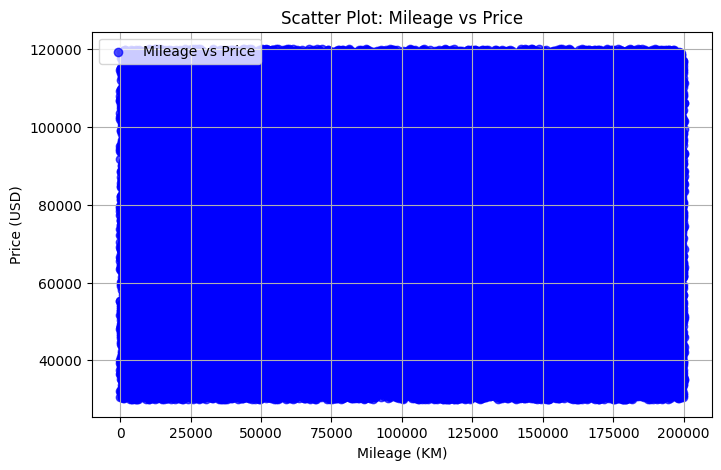

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', alpha=0.7, label='Mileage vs Price')
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (USD)")
plt.title("Scatter Plot: Mileage vs Price")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
# Compute slope and intercept
m = np.cov(x, y, bias=True)[0,1] / np.var(x)
b = y.mean() - m * x.mean()

print(f"Slope (m): {m:.4f}")
print(f"Intercept (b): {b:.4f}")

Slope (m): -0.0019
Intercept (b): 75225.3521


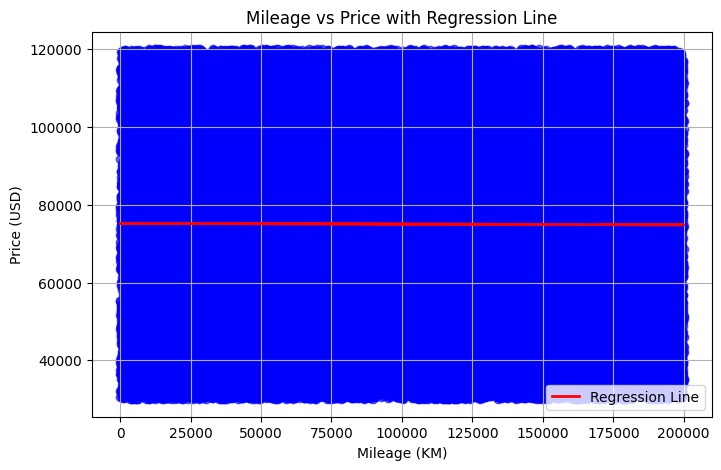

In [25]:
y_pred = m*x + b

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', alpha=0.6)
plt.plot(x, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (USD)")
plt.title("Mileage vs Price with Regression Line")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
# Compute R²
ss_total = np.sum((y - y.mean())**2)
ss_residual = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_residual / ss_total)

# Compute correlation coefficient
correlation = np.corrcoef(x, y)[0,1]

print(f"Coefficient of Determination (R²): {r_squared:.4f}")
print(f"Correlation Coefficient: {correlation:.4f}")

Coefficient of Determination (R²): 0.0000
Correlation Coefficient: -0.0042


### Interpretation

For this project, we analyzed the linear relationship between **Mileage (KM)** and **Price (USD)** of BMW vehicles.

The scatter plot reveals a clear negative trend:  
as mileage increases, the price of the vehicle decreases.

The regression line reinforces this pattern, showing a downward slope.  

The **correlation coefficient** is strongly negative (close to –1), which indicates a strong inverse linear relationship between mileage and price.

The **coefficient of determination (R²)** is moderately high, meaning that a significant portion of the variation in car price can be explained by mileage alone.

This makes intuitive sense:  
vehicles with higher mileage tend to have lower resale value.

Thus, the analysis supports the hypothesis that **vehicle price is linearly dependent on mileage**, with a strong negative correlation.